In [1]:
import os

**Dataset Link**
https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression

In [3]:
df = pd.read_csv("/kaggle/input/eergy-efficiency-dataset/ENB2012_data.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
df = df.rename(columns={
    'X1': 'Relative Compactness',
    'X2': 'Surface Area',
    'X3': 'Wall Area',
    'X4': 'Roof Area',
    'X5': 'Overall Height',
    'X6': 'Orientation',
    'X7': 'Glazing Area',
    'X8': 'Glazing Area Distribution',
    'Y1': 'Heating Load',
    'Y2': 'Cooling Load'
})

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [6]:
# Check for the null values
df.isnull().sum()

Relative Compactness         0
Surface Area                 0
Wall Area                    0
Roof Area                    0
Overall Height               0
Orientation                  0
Glazing Area                 0
Glazing Area Distribution    0
Y1                           0
Y2                           0
dtype: int64

In [7]:
# Check the datatypes for encoding
df.dtypes

Relative Compactness         float64
Surface Area                 float64
Wall Area                    float64
Roof Area                    float64
Overall Height               float64
Orientation                    int64
Glazing Area                 float64
Glazing Area Distribution      int64
Y1                           float64
Y2                           float64
dtype: object

In [5]:
# Copy the contents of the dataset
df_original = df.copy()
df_copy = df.copy()
print("Dataset copied successfully!")

Dataset copied successfully!


In [6]:
# Encoding the categorical values
import pickle

encoders = {}
for col in df_copy.columns:
    if df_copy[col].dtype == 'object':
        encoder = LabelEncoder()
        df_copy[col] = encoder.fit_transform(df_copy[col])
        encoders[col] = encoder

with open("bayesian_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Bayesian encoders loaded successfully!")

Bayesian encoders loaded successfully!


In [15]:
# Check the datatypes after encoding
df_copy.dtypes

Relative Compactness         float64
Surface Area                 float64
Wall Area                    float64
Roof Area                    float64
Overall Height               float64
Orientation                    int64
Glazing Area                 float64
Glazing Area Distribution      int64
Heating Load                 float64
Cooling Load                 float64
dtype: object

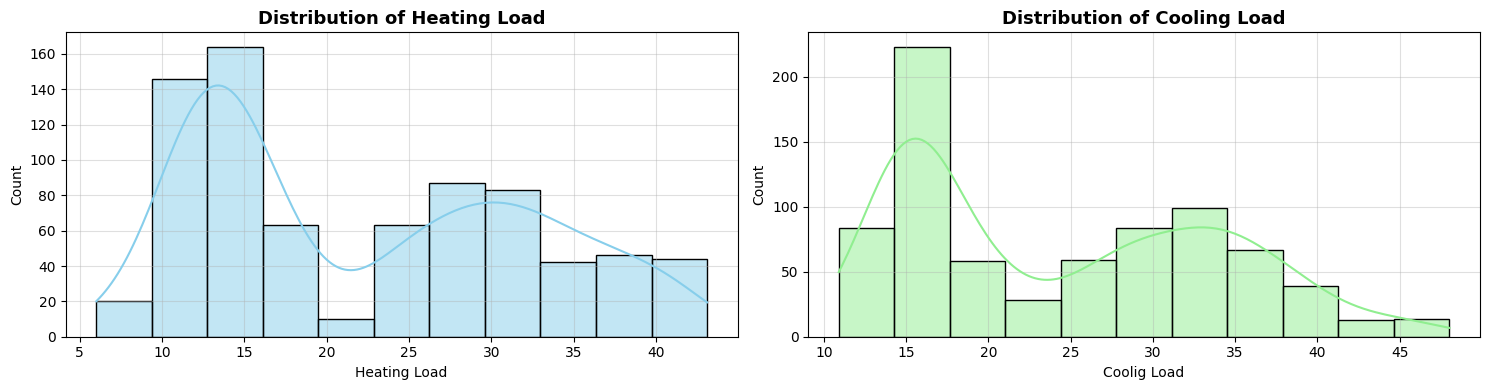

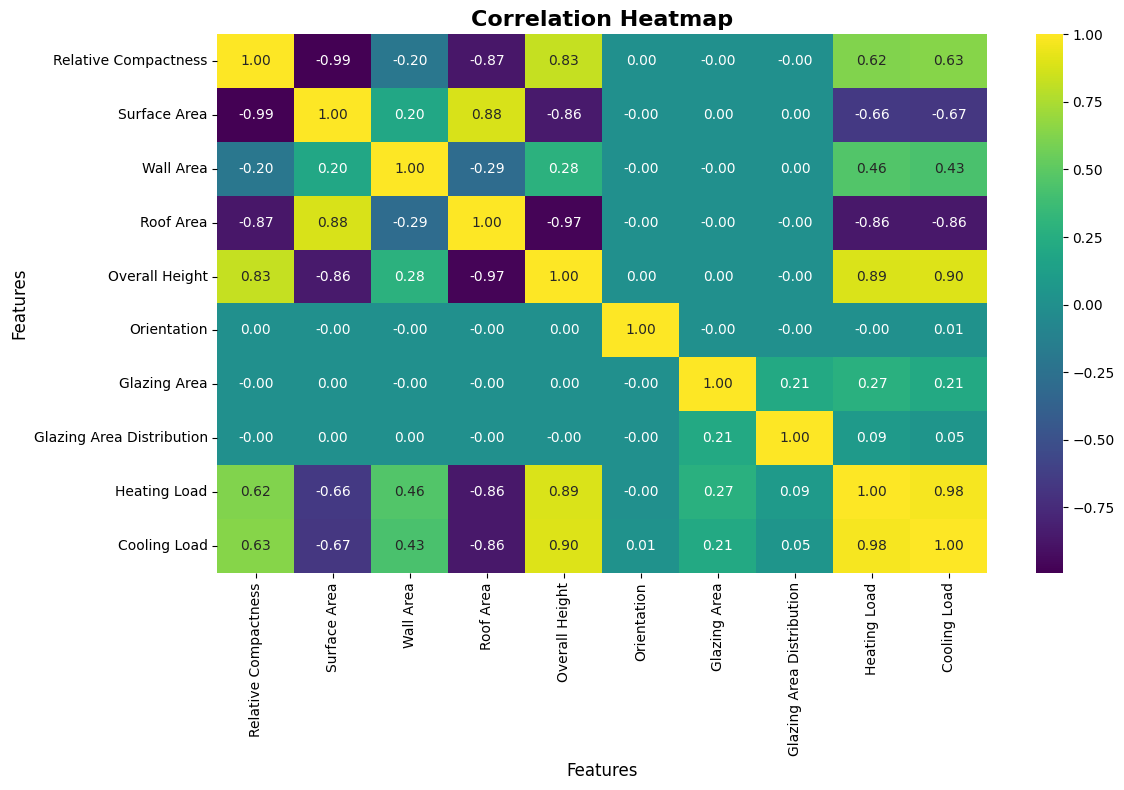

In [19]:
# Distribution Graph of Heating Load
plt.figure(figsize=(15, 4))

# Heating Load
plt.subplot(1, 2, 1)
sns.histplot(df_copy['Heating Load'], kde=True, color='skyblue')
plt.title("Distribution of Heating Load", fontsize=13, fontweight='bold')
plt.xlabel("Heating Load")
plt.ylabel("Count")
plt.grid(True, alpha=0.4)

# Cooling Load
plt.subplot(1, 2, 2)
sns.histplot(df_copy['Cooling Load'], kde=True, color='lightgreen')
plt.title("Distribution of Cooling Load", fontsize=13, fontweight='bold')
plt.xlabel("Coolig Load")
plt.ylabel("Count")
plt.grid(True, alpha=0.4)

# Showing the distribution graphs
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_copy.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Extract the independent and dependent variables
X = df.drop(columns=['Heating Load', 'Cooling Load'])
y = df[['Heating Load', 'Cooling Load']]

# Split into Train and Test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Scale the dataset and save the scalers
import pickle

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler using pickle
with open("bayesian_scalers.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Bayesian scalers dumped successfully!")

Bayesian scalers dumped successfully!


In [11]:
import optuna
from sklearn.linear_model import BayesianRidge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

def objective(trial):
    alpha_1 = trial.suggest_float('alpha_1', 1e-7, 1e-3, log=True)
    alpha_2 = trial.suggest_float('alpha_2', 1e-7, 1e-3, log=True)
    lambda_1 = trial.suggest_float('lambda_1', 1e-7, 1e-3, log=True)
    lambda_2 = trial.suggest_float('lambda_2', 1e-7, 1e-3, log=True)
    n_iter = trial.suggest_int('n_iter', 100, 500, step=100)
    tol = trial.suggest_float('tol', 1e-6, 1e-2, log=True)

    base_model = BayesianRidge(
        alpha_1=alpha_1,
        alpha_2=alpha_2,
        lambda_1=lambda_1,
        lambda_2=lambda_2,
        n_iter=n_iter,
        tol=tol
    )

    # Wrap with MultiOutputRegressor for multi-target regression
    model = MultiOutputRegressor(base_model)

    # Add scaling pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # R² as scoring metric
    score = cross_val_score(pipeline, X_train_scaled, y_train, cv=5, scoring='r2').mean()

    return score

In [12]:
# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Print results
print("Best Hyperparameters:", study.best_params)
print("Best R² Score:", study.best_value)

# Rebuild final model
best = study.best_params

bayesian_model = MultiOutputRegressor(BayesianRidge(
        alpha_1=best['alpha_1'],
        alpha_2=best['alpha_2'],
        lambda_1=best['lambda_1'],
        lambda_2=best['lambda_2'],
        n_iter=best['n_iter'],
        tol=best['tol']
    ))

# Fit and predict the model
bayesian_model.fit(X_train_scaled, y_train)
y_pred = bayesian_model.predict(X_test_scaled)

[I 2025-11-02 06:45:18,825] A new study created in memory with name: no-name-21f0f610-6387-468d-8272-637fec4aa694


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-02 06:45:18,909] Trial 0 finished with value: 0.8988031655653561 and parameters: {'alpha_1': 0.00019303707035118296, 'alpha_2': 0.0006039276479930524, 'lambda_1': 0.0002798433368692317, 'lambda_2': 3.296605451386442e-07, 'n_iter': 300, 'tol': 1.4419151171593383e-06}. Best is trial 0 with value: 0.8988031655653561.
[I 2025-11-02 06:45:18,950] Trial 1 finished with value: 0.8988031743621292 and parameters: {'alpha_1': 2.3191643482174018e-05, 'alpha_2': 9.0702657462059e-07, 'lambda_1': 4.817081565733896e-06, 'lambda_2': 2.0976875301715618e-07, 'n_iter': 200, 'tol': 1.6330311037420004e-06}. Best is trial 1 with value: 0.8988031743621292.
[I 2025-11-02 06:45:18,991] Trial 2 finished with value: 0.8988031439235373 and parameters: {'alpha_1': 5.2442257600067515e-05, 'alpha_2': 0.0007931837158120459, 'lambda_1': 0.0009517034749374437, 'lambda_2': 2.006280032192358e-05, 'n_iter': 500, 'tol': 2.238765766874261e-06}. Best is trial 1 with value: 0.8988031743621292.
[I 2025-11-02 06:45:1

In [13]:
df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


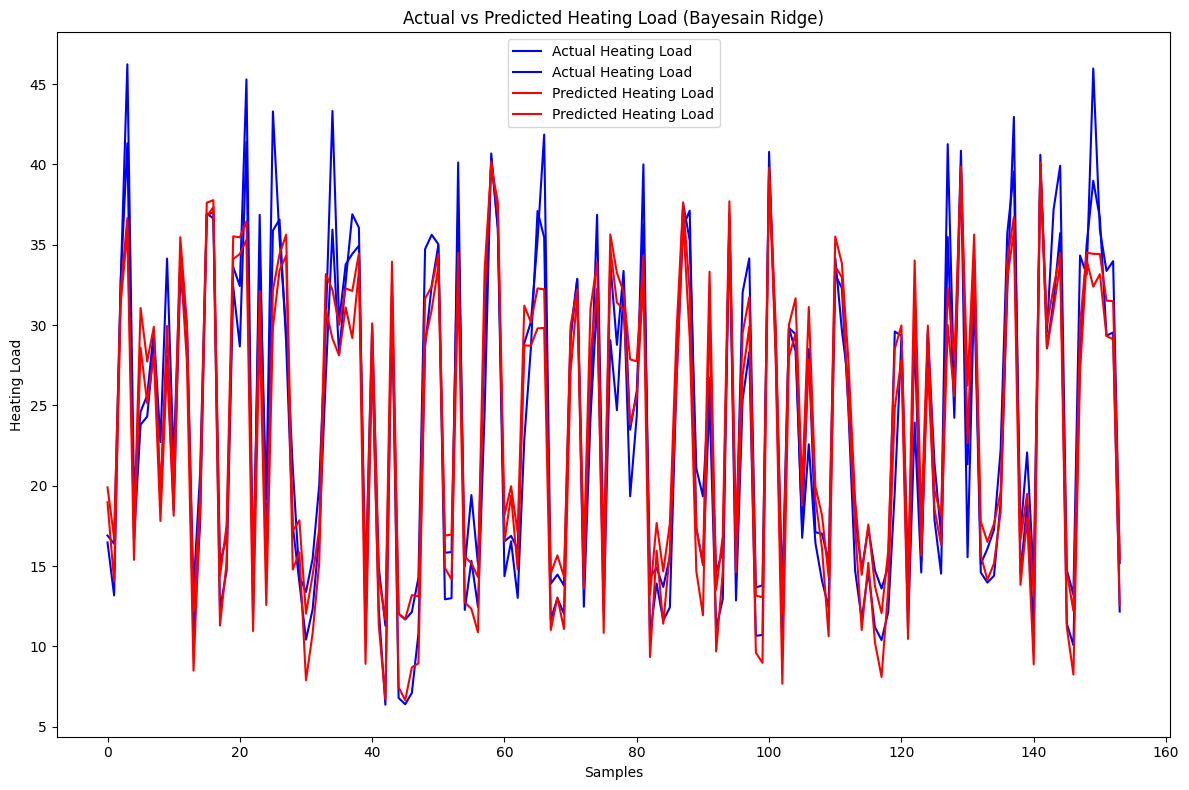

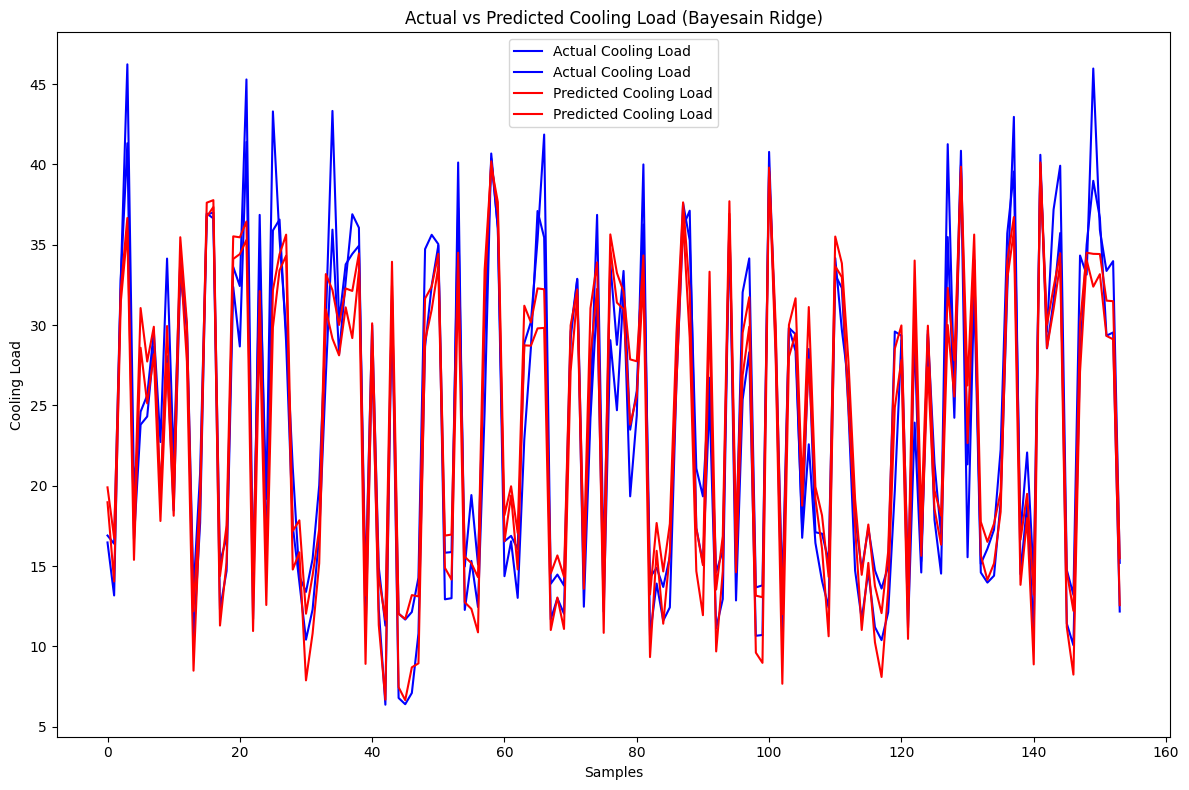

In [45]:
# Plot actual vs predicted
plt.figure(figsize=(12,8))
plt.plot(y_test.values, label='Actual Heating Load', color='blue')
plt.plot(y_pred, label='Predicted Heating Load', color='red')
plt.title('Actual vs Predicted Heating Load (Bayesain Ridge)')
plt.xlabel('Samples')
plt.ylabel('Heating Load')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
plt.plot(y_test.values, label='Actual Cooling Load', color='blue')
plt.plot(y_pred, label='Predicted Cooling Load', color='red')
plt.title('Actual vs Predicted Cooling Load (Bayesain Ridge)')
plt.xlabel('Samples')
plt.ylabel('Cooling Load')
plt.legend()

plt.tight_layout()
plt.show()

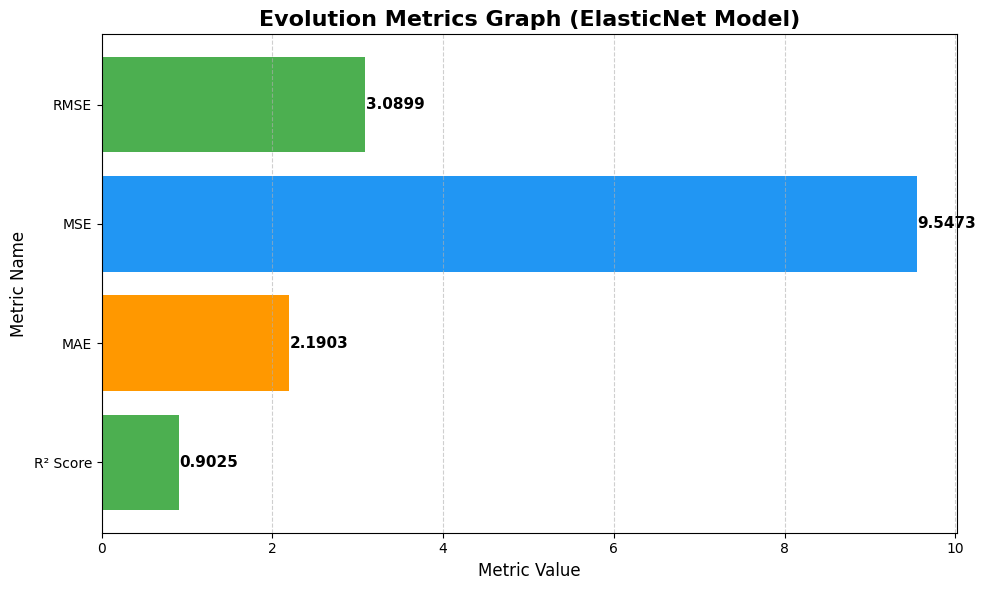

In [46]:
# Define metrics
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    'R² Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
}

# Create a figure
plt.figure(figsize=(10,6))

# Horizontal bar chart for better readability
plt.barh(list(metrics.keys()), list(metrics.values()), color=['#4CAF50', '#FF9800', '#2196F3'])

# Title and labels
plt.title('Evolution Metrics Graph (ElasticNet Model)', fontsize=16, fontweight='bold')
plt.xlabel('Metric Value', fontsize=12)
plt.ylabel('Metric Name', fontsize=12)

# Add metric values beside bars
for i, (key, value) in enumerate(metrics.items()):
    plt.text(value + 0.01, i, f"{value:.4f}", va='center', fontsize=11, fontweight='bold')

# Grid and style
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

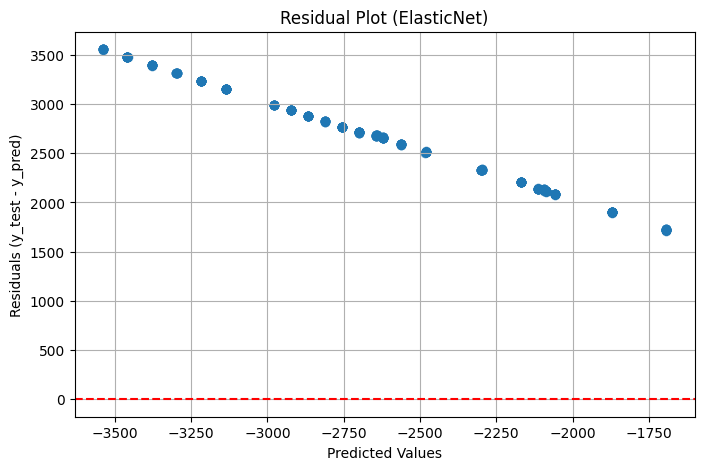

In [48]:
y_pred = bayesian_model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Residual plot (Predicted vs Residuals)
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot (ElasticNet)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y_test - y_pred)")
plt.grid(True)
plt.show()

In [14]:
# Import Optuna visualizations
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_contour,
    plot_param_importances,
    plot_edf,
    plot_slice,
    plot_intermediate_values
)

# Create list of all visualizations with descriptive names
plots = [
    ("Optimization History", plot_optimization_history(study)),
    ("Parallel Coordinate", plot_parallel_coordinate(study)),
    ("Contour Plot", plot_contour(study)),
    ("Parameter Importances", plot_param_importances(study)),
    ("Empirical Distribution Function (EDF)", plot_edf(study)),
    ("Parameter Slice Plot", plot_slice(study)),                # NEW — shows effect of each hyperparameter
    ("Intermediate Values (Learning Curve)", plot_intermediate_values(study))  # NEW — shows trial progress
]

# Display all plots in loop with clear titles
for name, fig in plots:
    print(f"\n {name}")
    fig.show()

[W 2025-11-02 06:45:37,917] You need to set up the pruning feature to utilize `plot_intermediate_values()`



 Optimization History



 Parallel Coordinate



 Contour Plot



 Parameter Importances



 Empirical Distribution Function (EDF)



 Parameter Slice Plot



 Intermediate Values (Learning Curve)



📈 Optimization History


<Figure size 2000x1200 with 0 Axes>

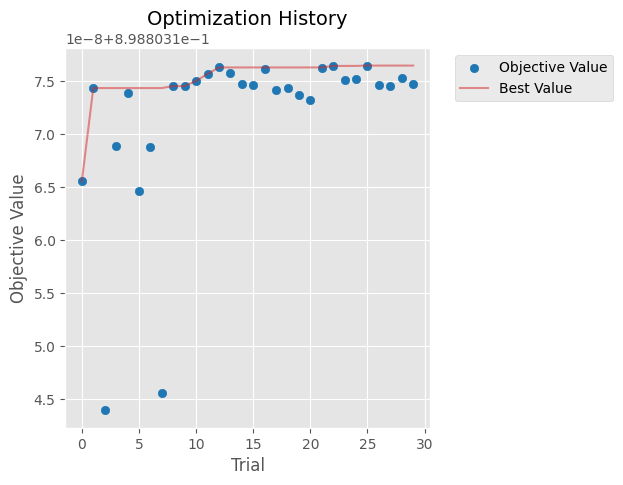


📈 Parallel Coordinate


<Figure size 2000x1200 with 0 Axes>

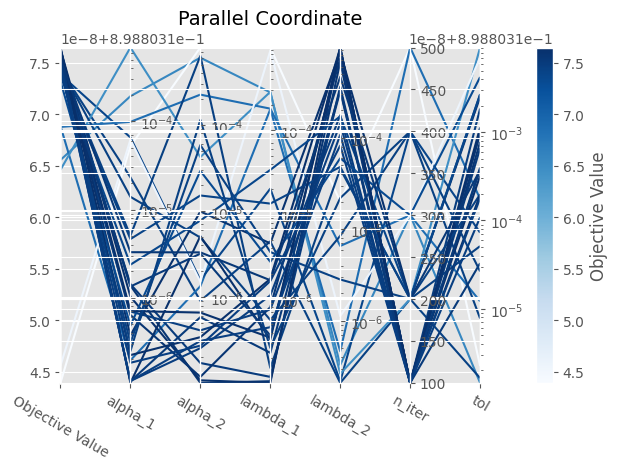


📈 Parameter Importances


<Figure size 2000x1200 with 0 Axes>

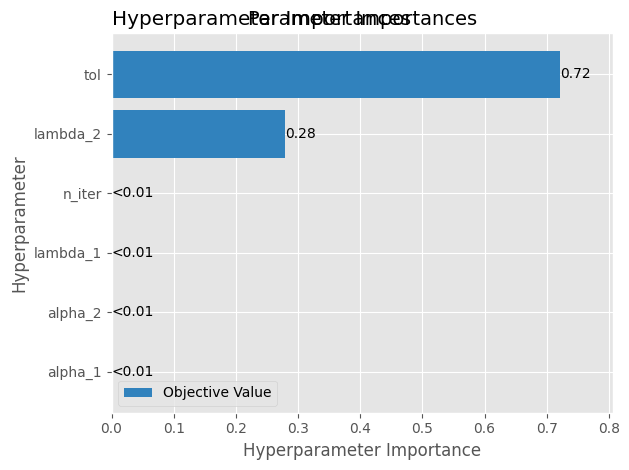


📈 Empirical Distribution Function (EDF)


<Figure size 2000x1200 with 0 Axes>

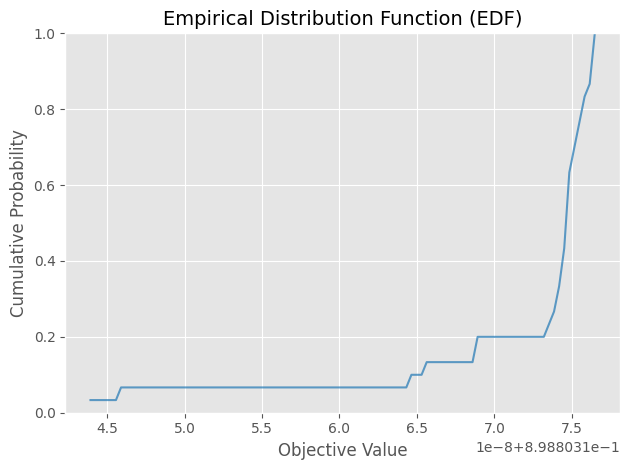


📈 Parameter Slice Plot


<Figure size 2000x1200 with 0 Axes>

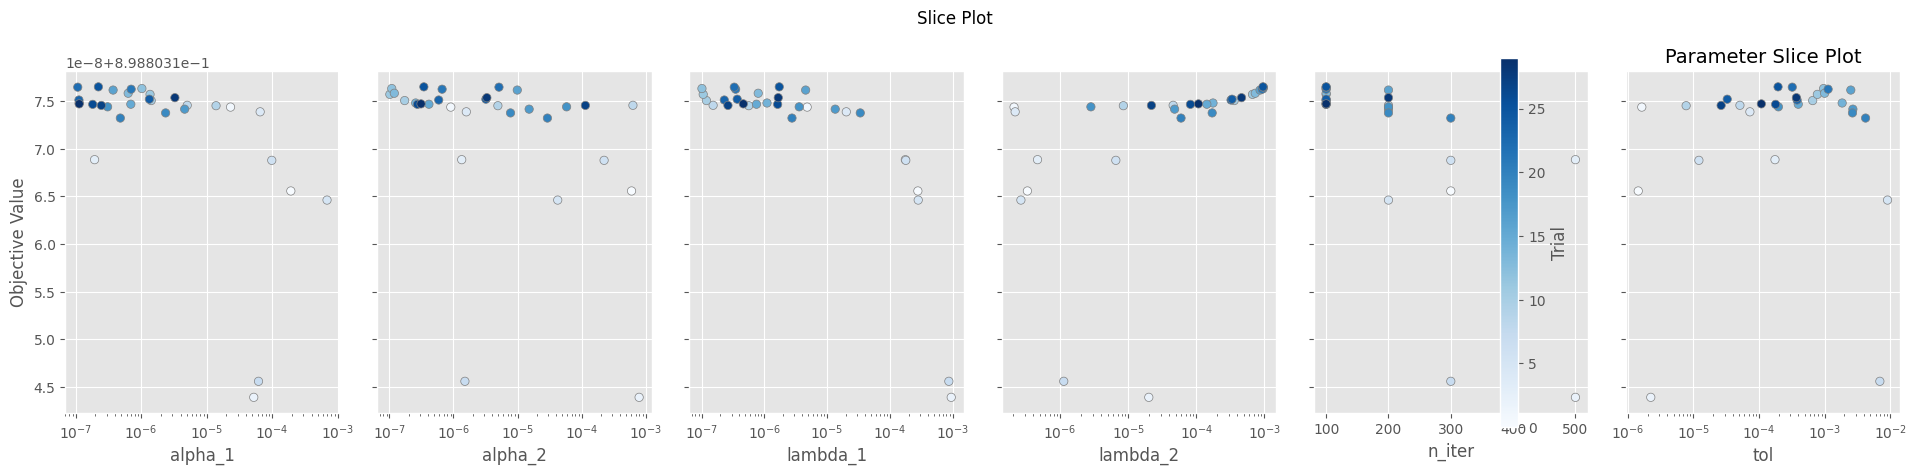

[W 2025-11-02 06:46:05,589] You need to set up the pruning feature to utilize `plot_intermediate_values()`



📈 Intermediate Values (Learning Curve)


<Figure size 2000x1200 with 0 Axes>

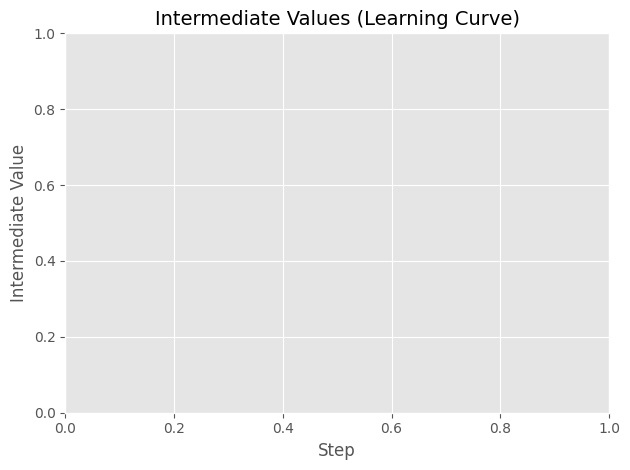

In [15]:
# 📊 OPTUNA VISUALIZATIONS (Matplotlib)
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
    plot_edf,
    plot_slice,
    plot_intermediate_values
)
import matplotlib.pyplot as plt

# List of all plots with descriptive names and plotting functions
plots = [
    ("Optimization History", plot_optimization_history),
    ("Parallel Coordinate", plot_parallel_coordinate),
    ("Parameter Importances", plot_param_importances),
    ("Empirical Distribution Function (EDF)", plot_edf),
    ("Parameter Slice Plot", plot_slice),
    ("Intermediate Values (Learning Curve)", plot_intermediate_values)
]

# Display all plots properly resized
for name, plot_func in plots:
    print(f"\n📈 {name}")
    
    # Create a fresh figure with desired size
    plt.figure(figsize=(20,12))
    
    # Call the plotting function directly on this figure
    ax = plot_func(study)
    
    # Add title (use suptitle if it's a figure)
    if hasattr(ax, "set_title"):
        ax.set_title(name, fontsize=14)
    else:
        plt.title(name, fontsize=14)
    
    plt.tight_layout()
    plt.show()

In [16]:
import joblib
from sklearn.pipeline import make_pipeline

# Create the pipeline
pipe = make_pipeline(scaler, bayesian_model)
pipe.fit(X_train, y_train)

# Save the trained pipeline
joblib.dump(pipe, "bayesian_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!
